#  Práctica 1 - Evaporación vs Precipitación

Licenciatura en Física — Facultad de Ciencias, UNAM

Karla Cecila Valeria Ríos Lara

24 Septiembre 2026

# Introducción y objetivos

**Introducción**

¿Qué es el ciclo hidrológico?

El ciclo hidrológico constituye uno de los componentes fundamentales del sistema climático, este relaciona la evaporación desde la superficie, el transporte atmosférico de vapor de agua y la precipitación. En una escala global, la conservación de la masa de agua implica que, para periodos climatológicos suficientemente largos, la precipitación media global debe ser aproximadamente compensada por la evaporación. Este equilibrio no necesariamente se cumple de manera local o regional, por al transporte horizontal de humedad realizado por la circulación atmosférica.
En la práctica se utilizan datos del reanálisis ERA5 correspondientes al periodo 1991–2020 para analizar la climatología de precipitación y evaporación.

A partir de estas variables se estudia el balance \(P-E\), tanto globalmente como para una región seleccionada, y se relacionan sus características espaciales y estacionales con el transporte integrado de humedad atmosférica.

¿De qué manera se relacionan las diferencias entre precipitación y evaporación a escala global y regional con el transporte atmosférico de humedad?

**Objetivo**

Tenemos que evaluar, mediante datos de ERA5, el balance climatológico entre precipitación y evaporación a escala global y regional, interpretando las diferencias observadas a partir de la conservación de la masa y del transporte atmosférico de humedad.

**Fundamento teórico**

El balance hidrológico atmosférico está determinado principalmente por la evaporación, la precipitación y el transporte de vapor de agua. La evaporación \(E\) representa el flujo de agua desde la superficie hacia la atmósfera, mientras que la precipitación \(P\) constituye una transferencia de agua desde la atmósfera hacia la superficie.
La diferencia \(P-E\) permite identificar el comportamiento climatológico de una región. Valores positivos indican que la precipitación supera a la evaporación, mientras que valores negativos indican que la evaporación es mayor.

El transporte horizontal de humedad integrado verticalmente puede expresarse como:
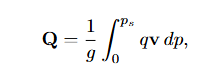


donde \(q\) es la humedad específica, \(\mathbf v\) el viento horizontal, \(p\) la presión y \(g\) la aceleración gravitacional.
La conservación de humedad atmosférica permite relacionar dicho transporte con precipitación y evaporación mediante

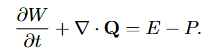

Para un promedio climatológico de largo periodo, el término de almacenamiento de humedad es pequeño, por lo que aproximadamente

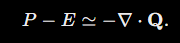

Por ello, regiones con \(P-E>0\) están asociadas con convergencia neta de humedad, mientras que aquellas con \(P-E<0\) presentan divergencia neta de humedad.



In [ ]:
!pip install cartopy
import cartopy

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 9.5/9.5 MB 66.0 MB/s eta 0:00:00


/usr/local/lib/python3.13/dist-packages/pyproj/network.py:59: UserWarning: pyproj unable to set PROJ database path.
  _set_context_ca_bundle_path(ca_bundle_path)


In [ ]:
!pip install cartopy netCDF4

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 9.5/9.5 MB 21.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 10.1/10.1 MB 58.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.6/1.6 MB 58.1 MB/s eta 0:00:00


In [ ]:
import numpy as np
import pandas as pd
import xarray as xr
import matplotlib.pyplot as plt
import cartopy.crs as ccrs
import cartopy.feature as cfeature

In [ ]:
from google.colab import files

uploaded = files.upload()

Saving f6ce3d60371760b2df4bd863c1d821e8.grib to f6ce3d60371760b2df4bd863c1d821e8.grib


In [ ]:
!pip install -q cfgrib

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 56.1/56.1 kB 2.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 49.1/49.1 kB 4.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 91.6/91.6 kB 6.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 9.1/9.1 MB 86.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 36.0/36.0 MB 19.8 MB/s eta 0:00:00


In [ ]:
import xarray as xr
import os

# Ver los archivos que hay en Colab
print(os.listdir("/content"))

['.config', 'f6ce3d60371760b2df4bd863c1d821e8.grib', 'sample_data']


In [ ]:
archivo = "/content/f6ce3d60371760b2df4bd863c1d821e8.grib"

ds = xr.open_dataset(archivo, engine="cfgrib")
ds

<xarray.Dataset> Size: 1GB
Dimensions:     (time: 360, latitude: 721, longitude: 1440)
Coordinates:
  * time        (time) datetime64[ns] 3kB 1990-12-31T18:00:00 ... 2020-11-30T...
  * latitude    (latitude) float64 6kB 90.0 89.75 89.5 ... -89.5 -89.75 -90.0
  * longitude   (longitude) float64 12kB 0.0 0.25 0.5 0.75 ... 359.2 359.5 359.8
    number      int64 8B ...
    step        timedelta64[ns] 8B ...
    surface     float64 8B ...
    valid_time  (time) datetime64[ns] 3kB ...
Data variables:
    tp          (time, latitude, longitude) float32 1GB ...
Attributes:
    GRIB_edition:            1
    GRIB_centre:             ecmf
    GRIB_centreDescription:  European Centre for Medium-Range Weather Forecasts
    GRIB_subCentre:          0
    Conventions:             CF-1.7
    institution:             European Centre for Medium-Range Weather Forecasts
    history:                 2026-09-25T21:09 GRIB to CDM+CF via cfgrib-0.9.1...

In [ ]:
# Extraemos la precipitación total
P = ds["tp"]

# Revisamos información de la variable
print(P)
print("\nUnidades:", P.attrs.get("units"))

<xarray.DataArray 'tp' (time: 360, latitude: 721, longitude: 1440)> Size: 1GB
[373766400 values with dtype=float32]
Coordinates:
  * time        (time) datetime64[ns] 3kB 1990-12-31T18:00:00 ... 2020-11-30T...
  * latitude    (latitude) float64 6kB 90.0 89.75 89.5 ... -89.5 -89.75 -90.0
  * longitude   (longitude) float64 12kB 0.0 0.25 0.5 0.75 ... 359.2 359.5 359.8
    number      int64 8B ...
    step        timedelta64[ns] 8B ...
    surface     float64 8B ...
    valid_time  (time) datetime64[ns] 3kB ...
Attributes: (12/31)
    GRIB_paramId:                             228
    GRIB_dataType:                            fc
    GRIB_numberOfPoints:                      1038240
    GRIB_typeOfLevel:                         surface
    GRIB_stepUnits:                           1
    GRIB_stepType:                            avgad
    ...                                       ...
    GRIB_shortName:                           tp
    GRIB_totalNumber:                         0
    GRIB_uni

In [ ]:
# Convertir precipitación de m/día a mm/día
P_mm_day = P * 1000

# Actualizamos las unidades
P_mm_day.attrs["units"] = "mm/day"

print(P_mm_day)

<xarray.DataArray 'tp' (time: 360, latitude: 721, longitude: 1440)> Size: 1GB
array([[[0.6160736 , 0.6160736 , 0.6160736 , ..., 0.6160736 ,
         0.6160736 , 0.6160736 ],
        [0.64849854, 0.64849854, 0.64849854, ..., 0.64849854,
         0.64849854, 0.64849854],
        [0.6904602 , 0.6904602 , 0.6904602 , ..., 0.6904602 ,
         0.6904602 , 0.6904602 ],
        ...,
        [0.04959106, 0.04959106, 0.04959106, ..., 0.04959106,
         0.04959106, 0.04959106],
        [0.05340576, 0.05340576, 0.05340576, ..., 0.05340576,
         0.05340576, 0.05340576],
        [0.0629425 , 0.0629425 , 0.0629425 , ..., 0.0629425 ,
         0.0629425 , 0.0629425 ]],

       [[0.17642975, 0.17642975, 0.17642975, ..., 0.17642975,
         0.17642975, 0.17642975],
        [0.17356873, 0.17356873, 0.17356873, ..., 0.17356873,
         0.17356873, 0.17356873],
        [0.18692017, 0.18692017, 0.18692017, ..., 0.18787384,
         0.18787384, 0.18787384],
...
        [0.30517578, 0.30517578, 0.3051

In [ ]:
# Climatología mensual 1991-2020
P_clim = P_mm_day.groupby("time.month").mean(dim="time")

print(P_clim)

<xarray.DataArray 'tp' (month: 12, latitude: 721, longitude: 1440)> Size: 50MB
array([[[0.3751119 , 0.3751119 , 0.3751119 , ..., 0.3751119 ,
         0.3751119 , 0.3751119 ],
        [0.3777822 , 0.37790933, 0.37787756, ..., 0.3777822 ,
         0.3777504 , 0.37781397],
        [0.3813108 , 0.38143793, 0.38143793, ..., 0.38134256,
         0.3813108 , 0.38137436],
        ...,
        [0.13373692, 0.13367335, 0.13364156, ..., 0.13373692,
         0.13373692, 0.13373692],
        [0.13427734, 0.13418198, 0.13418198, ..., 0.13434093,
         0.13427734, 0.13427734],
        [0.15033086, 0.15033086, 0.15033086, ..., 0.15033086,
         0.15033086, 0.15033086]],

       [[0.41971207, 0.41971207, 0.41971207, ..., 0.41971207,
         0.41971207, 0.41971207],
        [0.42610168, 0.42616525, 0.42616525, ..., 0.42613348,
         0.42616525, 0.42616525],
        [0.42362213, 0.42362213, 0.42355856, ..., 0.4236857 ,
         0.42362213, 0.42362213],
...
        [0.09934107, 0.09940466, 0.099

In [ ]:
import numpy as np

# Pesos según la latitud
weights = np.cos(np.deg2rad(P_clim.latitude))

# Promedio global ponderado
P_global = P_clim.weighted(weights).mean(
    dim=("latitude", "longitude")
)

print(P_global)

<xarray.DataArray 'tp' (month: 12)> Size: 96B
array([2.89166199, 2.86721557, 2.86768881, 2.91447374, 2.99965105,
       3.01493431, 2.987114  , 2.94338569, 2.9102213 , 2.91291308,
       2.9228377 , 2.91091122])
Coordinates:
  * month    (month) int64 96B 1 2 3 4 5 6 7 8 9 10 11 12
    number   int64 8B 0
    step     timedelta64[ns] 8B 12:00:00
    surface  float64 8B 0.0
Attributes: (12/31)
    GRIB_paramId:                             228
    GRIB_dataType:                            fc
    GRIB_numberOfPoints:                      1038240
    GRIB_typeOfLevel:                         surface
    GRIB_stepUnits:                           1
    GRIB_stepType:                            avgad
    ...                                       ...
    GRIB_shortName:                           tp
    GRIB_totalNumber:                         0
    GRIB_units:                               m
    long_name:                                Total precipitation
    units:                          

In [ ]:
meses = [
    "Enero", "Febrero", "Marzo", "Abril",
    "Mayo", "Junio", "Julio", "Agosto",
    "Septiembre", "Octubre", "Noviembre", "Diciembre"
]

for mes, valor in zip(meses, P_global.values):
    print(f"{mes:12s}: {valor:.3f} mm/día")

Enero       : 2.892 mm/día
Febrero     : 2.867 mm/día
Marzo       : 2.868 mm/día
Abril       : 2.914 mm/día
Mayo        : 3.000 mm/día
Junio       : 3.015 mm/día
Julio       : 2.987 mm/día
Agosto      : 2.943 mm/día
Septiembre  : 2.910 mm/día
Octubre     : 2.913 mm/día
Noviembre   : 2.923 mm/día
Diciembre   : 2.911 mm/día


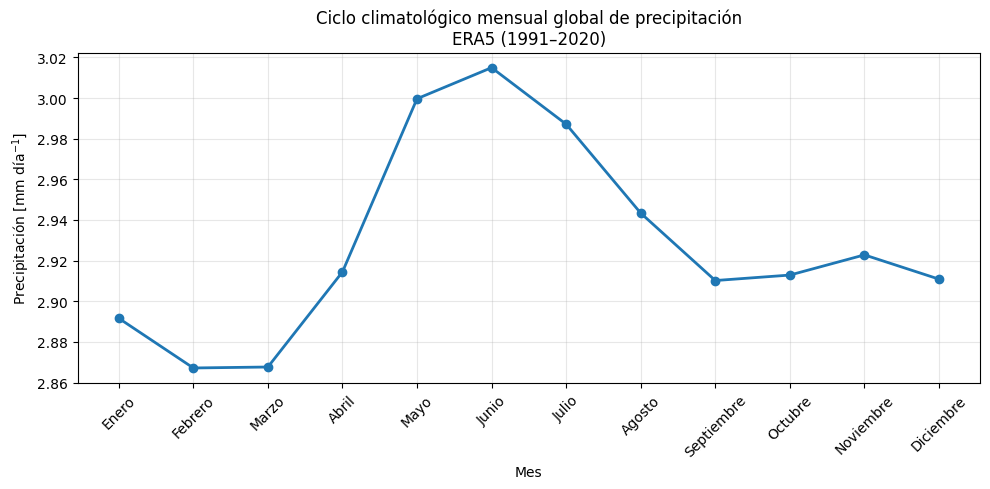

In [ ]:
import matplotlib.pyplot as plt

plt.figure(figsize=(10, 5))

plt.plot(
    meses,
    P_global.values,
    marker="o",
    linewidth=2
)

plt.xlabel("Mes")
plt.ylabel("Precipitación [mm día$^{-1}$]")
plt.title(
    "Ciclo climatológico mensual global de precipitación\n"
    "ERA5 (1991–2020)"
)

plt.xticks(rotation=45)
plt.grid(alpha=0.3)
plt.tight_layout()

plt.show()

El ciclo climatológico mensual global de precipitación para el periodo 1991–2020 presenta una variación estacional relativamente pequeña. Los valores se mantienen aproximadamente entre 2.87 y 3.02 mm día^-1. El máximo ocurre alrededor de junio, mientras que los valores mínimos se presentan entre febrero y marzo. La amplitud reducida del ciclo global se debe a que el promedio espacial integra regiones con diferentes regímenes y estaciones de precipitación.



# Evaporación

In [ ]:
from google.colab import files

uploaded = files.upload()

Saving 3f20e0210e9967f67cca8d5b4a7dd634.grib to 3f20e0210e9967f67cca8d5b4a7dd634.grib


In [ ]:
archivo_E = "/content/3f20e0210e9967f67cca8d5b4a7dd634.grib"

ds_E = xr.open_dataset(archivo_E, engine="cfgrib")

ds_E

<xarray.Dataset> Size: 1GB
Dimensions:     (time: 360, latitude: 721, longitude: 1440)
Coordinates:
  * time        (time) datetime64[ns] 3kB 1990-12-31T18:00:00 ... 2020-11-30T...
  * latitude    (latitude) float64 6kB 90.0 89.75 89.5 ... -89.5 -89.75 -90.0
  * longitude   (longitude) float64 12kB 0.0 0.25 0.5 0.75 ... 359.2 359.5 359.8
    number      int64 8B ...
    step        timedelta64[ns] 8B ...
    surface     float64 8B ...
    valid_time  (time) datetime64[ns] 3kB ...
Data variables:
    e           (time, latitude, longitude) float32 1GB ...
Attributes:
    GRIB_edition:            1
    GRIB_centre:             ecmf
    GRIB_centreDescription:  European Centre for Medium-Range Weather Forecasts
    GRIB_subCentre:          0
    Conventions:             CF-1.7
    institution:             European Centre for Medium-Range Weather Forecasts
    history:                 2026-09-26T02:04 GRIB to CDM+CF via cfgrib-0.9.1...

In [ ]:
E = ds_E["e"]

print(E)
print("\nUnidades:", E.attrs.get("units"))
print("Nombre:", E.attrs.get("long_name"))

<xarray.DataArray 'e' (time: 360, latitude: 721, longitude: 1440)> Size: 1GB
[373766400 values with dtype=float32]
Coordinates:
  * time        (time) datetime64[ns] 3kB 1990-12-31T18:00:00 ... 2020-11-30T...
  * latitude    (latitude) float64 6kB 90.0 89.75 89.5 ... -89.5 -89.75 -90.0
  * longitude   (longitude) float64 12kB 0.0 0.25 0.5 0.75 ... 359.2 359.5 359.8
    number      int64 8B ...
    step        timedelta64[ns] 8B ...
    surface     float64 8B ...
    valid_time  (time) datetime64[ns] 3kB ...
Attributes: (12/31)
    GRIB_paramId:                             182
    GRIB_dataType:                            fc
    GRIB_numberOfPoints:                      1038240
    GRIB_typeOfLevel:                         surface
    GRIB_stepUnits:                           1
    GRIB_stepType:                            avgad
    ...                                       ...
    GRIB_shortName:                           e
    GRIB_totalNumber:                         0
    GRIB_units

In [ ]:
E_mm_day = -E * 1000

E_mm_day.attrs["units"] = "mm/day"
E_mm_day.attrs["long_name"] = "Evaporation"

print("Mínimo:", float(E_mm_day.min()), "mm/día")
print("Máximo:", float(E_mm_day.max()), "mm/día")

Mínimo: -1.967117190361023 mm/día
Máximo: 20.49663734436035 mm/día


In [ ]:
E_clim = E_mm_day.groupby("time.month").mean(dim="time")

print(E_clim)

<xarray.DataArray 'e' (month: 12, latitude: 721, longitude: 1440)> Size: 50MB
array([[[ 0.02435197,  0.02435197,  0.02435197, ...,  0.02435197,
          0.02435197,  0.02435197],
        [ 0.02009223,  0.02008428,  0.02016375, ...,  0.02010018,
          0.02008428,  0.02011607],
        [ 0.02300888,  0.02300888,  0.02304862, ...,  0.02300094,
          0.02300888,  0.02300888],
        ...,
        [-0.01315922, -0.01315922, -0.01315922, ..., -0.01311948,
         -0.01313537, -0.01314332],
        [-0.01268238, -0.01269827, -0.01269827, ..., -0.01268238,
         -0.01268238, -0.01268238],
        [-0.0115936 , -0.0115936 , -0.0115936 , ..., -0.0115936 ,
         -0.0115936 , -0.0115936 ]],

       [[ 0.02486445,  0.02486445,  0.02486445, ...,  0.02486445,
          0.02486445,  0.02486445],
        [ 0.02507108,  0.02508697,  0.02508697, ...,  0.02511876,
          0.02511081,  0.02510286],
        [ 0.02639033,  0.02639827,  0.02637443, ...,  0.02651748,
          0.0264539 ,  0.

In [ ]:
weights_E = np.cos(np.deg2rad(E_clim.latitude))

E_global = E_clim.weighted(weights_E).mean(
    dim=("latitude", "longitude"))

print(E_global)

<xarray.DataArray 'e' (month: 12)> Size: 96B
array([2.86114238, 2.84709965, 2.86898435, 2.93043368, 3.02862388,
       3.03268606, 2.95936457, 2.89080182, 2.85005292, 2.8587615 ,
       2.87194661, 2.86867937])
Coordinates:
  * month    (month) int64 96B 1 2 3 4 5 6 7 8 9 10 11 12
    number   int64 8B 0
    step     timedelta64[ns] 8B 12:00:00
    surface  float64 8B 0.0
Attributes: (12/31)
    GRIB_paramId:                             182
    GRIB_dataType:                            fc
    GRIB_numberOfPoints:                      1038240
    GRIB_typeOfLevel:                         surface
    GRIB_stepUnits:                           1
    GRIB_stepType:                            avgad
    ...                                       ...
    GRIB_shortName:                           e
    GRIB_totalNumber:                         0
    GRIB_units:                               m of water equivalent
    long_name:                                Evaporation
    units:                

In [ ]:
for mes, valor in zip(meses, E_global.values):
    print(f"{mes:12s}: {valor:.3f} mm/día")

Enero       : 2.861 mm/día
Febrero     : 2.847 mm/día
Marzo       : 2.869 mm/día
Abril       : 2.930 mm/día
Mayo        : 3.029 mm/día
Junio       : 3.033 mm/día
Julio       : 2.959 mm/día
Agosto      : 2.891 mm/día
Septiembre  : 2.850 mm/día
Octubre     : 2.859 mm/día
Noviembre   : 2.872 mm/día
Diciembre   : 2.869 mm/día


In [ ]:
PE_global = P_global - E_global

print("BALANCE GLOBAL P - E\n")

for mes, valor in zip(meses, PE_global.values):
    print(f"{mes:12s}: {valor:+.4f} mm/día")

BALANCE GLOBAL P - E

Enero       : +0.0305 mm/día
Febrero     : +0.0201 mm/día
Marzo       : -0.0013 mm/día
Abril       : -0.0160 mm/día
Mayo        : -0.0290 mm/día
Junio       : -0.0178 mm/día
Julio       : +0.0277 mm/día
Agosto      : +0.0526 mm/día
Septiembre  : +0.0602 mm/día
Octubre     : +0.0542 mm/día
Noviembre   : +0.0509 mm/día
Diciembre   : +0.0422 mm/día


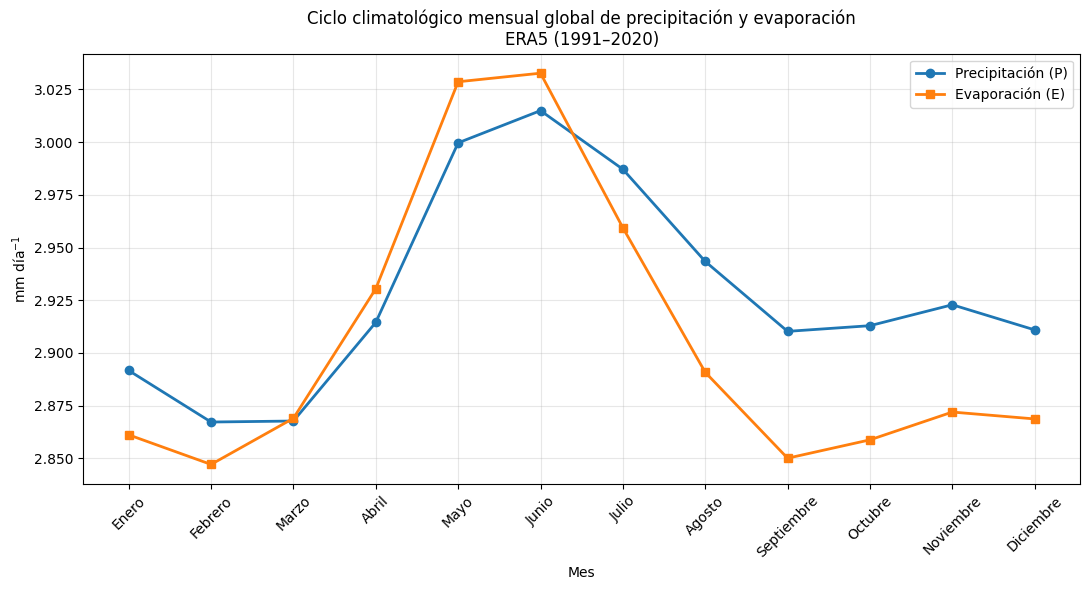

In [ ]:
plt.figure(figsize=(11, 6))

plt.plot(
    meses,
    P_global.values,
    marker="o",
    linewidth=2,
    label="Precipitación (P)"
)

plt.plot(meses, E_global.values, marker="s", linewidth=2, label="Evaporación (E)")

plt.xlabel("Mes")
plt.ylabel("mm día$^{-1}$")
plt.title("Ciclo climatológico mensual global de precipitación y evaporación\n""ERA5 (1991–2020)")

plt.xticks(rotation=45)
plt.grid(alpha=0.3)
plt.legend()
plt.tight_layout()

plt.show()

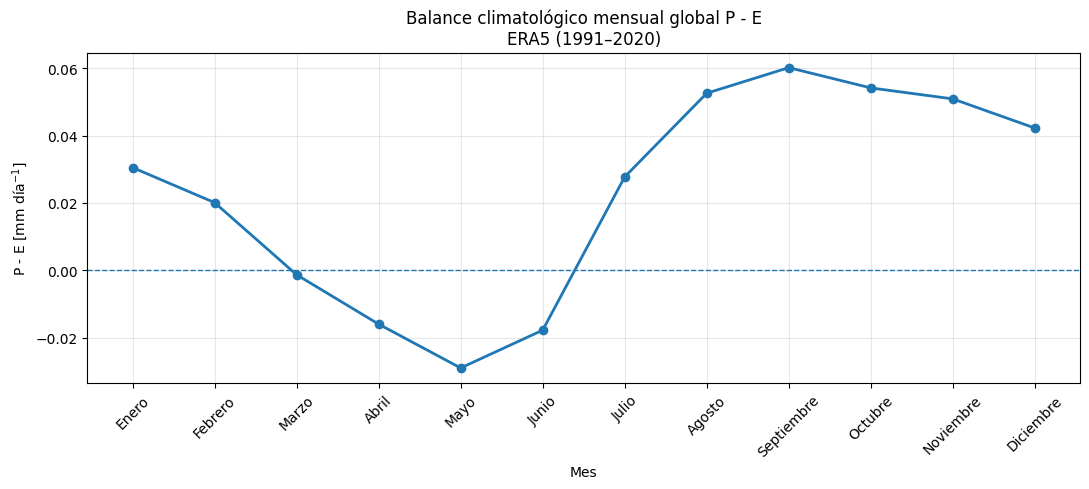

In [ ]:
plt.figure(figsize=(11, 5))

plt.axhline(y=0, linewidth=1, linestyle="--")

plt.plot(meses, PE_global.values, marker="o", linewidth=2)

plt.xlabel("Mes")
plt.ylabel("P - E [mm día$^{-1}$]")
plt.title("Balance climatológico mensual global P - E\n""ERA5 (1991–2020)")

plt.xticks(rotation=45)
plt.grid(alpha=0.3)
plt.tight_layout()

plt.show()

In [ ]:
P_anual = float(P_global.mean())
E_anual = float(E_global.mean())
PE_anual = P_anual - E_anual

error_relativo = (abs(PE_anual) /((P_anual + E_anual) / 2)) * 100

print("BALANCE GLOBAL ANUAL")
print("----------------------------")
print(f"P promedio = {P_anual:.4f} mm/día")
print(f"E promedio = {E_anual:.4f} mm/día")
print(f"P - E      = {PE_anual:+.4f} mm/día")
print(f"Error de cierre = {error_relativo:.2f} %")

BALANCE GLOBAL ANUAL
----------------------------
P promedio = 2.9286 mm/día
E promedio = 2.9057 mm/día
P - E      = +0.0229 mm/día
Error de cierre = 0.78 %


Balance global de precipitación y evaporación. Para el periodo climatológico 1991–2020 se obtuvo una precipitación media global de 2.9286 mm día^-1 y una evaporación media global de 2.9057 mm día^-1. La diferencia resultante fue P-E=0.0229 mm día^-1, correspondiente a un error relativo de cierre de aproximadamente \(0.78\%\). Estos resultados muestran que el balance hidrológico global presenta un cierre cercano a cero, consistente con la conservación de la masa de agua a escala planetaria. La pequeña diferencia residual puede asociarse con las características del reanálisis, el procesamiento de los datos y el hecho de que el balance obtenido no es perfectamente cerrado.

El pequeño valor de \(P-E\) respecto a las magnitudes individuales de \(P\) y \(E\), junto con un error de cierre de solo \(0.78\%\), indica que ERA5 reproduce un balance hidrológico global aproximadamente cerrado durante 1991–2020.

In [ ]:
# Límites aproximados de la región de México
lat_norte = 33
lat_sur = 14

lon_oeste = 242   # equivalente a -118°
lon_este = 274    # equivalente a -86°

# Recortar precipitación y evaporación
P_mex = P_clim.sel(latitude=slice(lat_norte, lat_sur), longitude=slice(lon_oeste, lon_este))

E_mex = E_clim.sel(latitude=slice(lat_norte, lat_sur), longitude=slice(lon_oeste, lon_este))

print("Dimensiones de precipitación:")
print(P_mex.sizes)

print("\nDimensiones de evaporación:")
print(E_mex.sizes)

Dimensiones de precipitación:
Frozen({'month': 12, 'latitude': 77, 'longitude': 129})

Dimensiones de evaporación:
Frozen({'month': 12, 'latitude': 77, 'longitude': 129})


In [ ]:
P_mex_mean = P_mex.weighted(weights_mex).mean(dim=("latitude", "longitude"))

E_mex_mean = E_mex.weighted(weights_mex).mean(dim=("latitude", "longitude"))

PE_mex = P_mex_mean - E_mex_mean

In [ ]:
print("BALANCE CLIMATOLÓGICO REGIONAL - MÉXICO")
print("------------------------------------------------")
print("Mes          P          E        P-E")
print("           mm/día     mm/día     mm/día")
print("------------------------------------------------")

for mes, p, e, pe in zip(meses, P_mex_mean.values, E_mex_mean.values, PE_mex.values): print(f"{mes:12s} "f"{p:7.3f}   "f"{e:7.3f}   "f"{pe:+7.3f}")

BALANCE CLIMATOLÓGICO REGIONAL - MÉXICO
------------------------------------------------
Mes          P          E        P-E
           mm/día     mm/día     mm/día
------------------------------------------------
Enero          1.098     2.923    -1.825
Febrero        0.926     2.929    -2.003
Marzo          0.908     2.848    -1.940
Abril          1.404     2.838    -1.434
Mayo           3.112     2.922    +0.190
Junio          3.346     3.069    +0.277
Julio          4.053     3.205    +0.848
Agosto         5.136     3.378    +1.758
Septiembre     3.246     3.499    -0.253
Octubre        1.862     3.478    -1.617
Noviembre      1.392     3.316    -1.923
Diciembre      1.334     3.099    -1.765


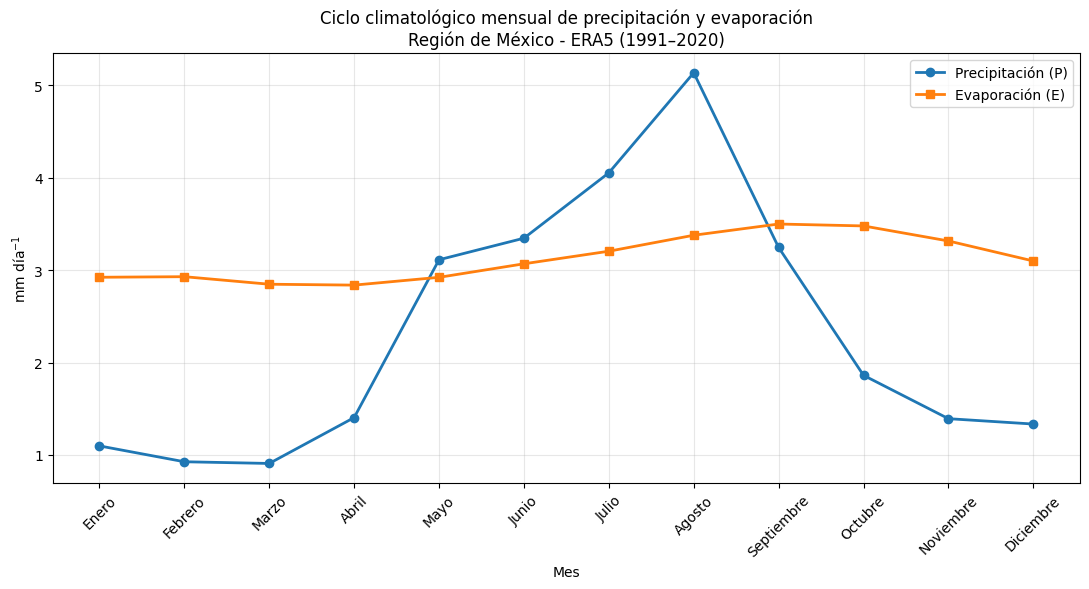

In [ ]:
plt.figure(figsize=(11,6))

plt.plot(meses, P_mex_mean.values, marker="o", linewidth=2, label="Precipitación (P)")

plt.plot(meses, E_mex_mean.values, marker="s", linewidth=2, label="Evaporación (E)")

plt.xlabel("Mes")
plt.ylabel("mm día$^{-1}$")

plt.title("Ciclo climatológico mensual de precipitación y evaporación\n""Región de México - ERA5 (1991–2020)")

plt.xticks(rotation=45)
plt.grid(alpha=0.3)
plt.legend()
plt.tight_layout()

plt.show()

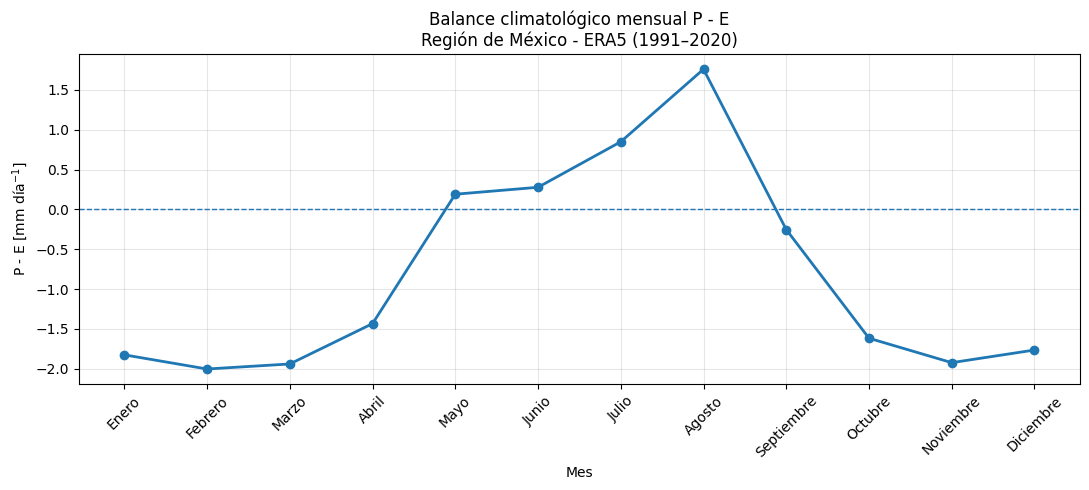

In [ ]:
plt.figure(figsize=(11,5))

plt.axhline(
    y=0,
    linestyle="--",
    linewidth=1
)

plt.plot(meses, PE_mex.values, marker="o", linewidth=2)

plt.xlabel("Mes")
plt.ylabel("P - E [mm día$^{-1}$]")

plt.title("Balance climatológico mensual P - E\n""Región de México - ERA5 (1991–2020)")

plt.xticks(rotation=45)
plt.grid(alpha=0.3)
plt.tight_layout()

plt.show()

In [ ]:
PE_max = float(PE_mex.max())
PE_min = float(PE_mex.min())

mes_max = int(PE_mex.argmax()) + 1
mes_min = int(PE_mex.argmin()) + 1

amplitud_PE = PE_max - PE_min

print("MAGNITUD Y ESTACIONALIDAD DE P-E")
print("--------------------------------")
print(f"Máximo P-E = {PE_max:+.3f} mm/día")
print(f"Mes máximo = {meses[mes_max-1]}")

print()

print(f"Mínimo P-E = {PE_min:+.3f} mm/día")
print(f"Mes mínimo = {meses[mes_min-1]}")

print()

print(f"Amplitud estacional = "f"{amplitud_PE:.3f} mm/día")

MAGNITUD Y ESTACIONALIDAD DE P-E
--------------------------------
Máximo P-E = +1.758 mm/día
Mes máximo = Agosto

Mínimo P-E = -2.003 mm/día
Mes mínimo = Febrero

Amplitud estacional = 3.761 mm/día


Análisis regional. El balance climatológico \(P-E\) para la región de México presenta una marcada variación estacional. El valor máximo es de \+1.758 mm día^-1 en agosto, mientras que el mínimo alcanza -2.003 mm día^-1 en febrero. La diferencia entre ambos extremos produce una amplitud estacional de 3.761 mm día^-1.
Los valores positivos de \(P-E\) indican periodos en los que la precipitación supera a la evaporación, mientras que los valores negativos corresponden a periodos en los que la evaporación es mayor que la precipitación. A diferencia del balance global, que se aproxima a cero en el promedio de largo plazo, el balance regional no tiene que cerrarse localmente debido al transporte de humedad por la circulación atmosférica.

In [ ]:
# Promedio climatológico anual de precipitación
P_anual_map = P_clim.mean(dim="month")

# Promedio climatológico anual de evaporación
E_anual_map = E_clim.mean(dim="month")

# Balance P-E
PE_anual_map = P_anual_map - E_anual_map

print(P_anual_map)
print(E_anual_map)
print(PE_anual_map)

<xarray.DataArray 'tp' (latitude: 721, longitude: 1440)> Size: 4MB
array([[0.70672303, 0.70672303, 0.70672303, ..., 0.70672303, 0.70672303,
        0.70672303],
       [0.7098754 , 0.70994693, 0.7099946 , ..., 0.7097986 , 0.7098251 ,
        0.7098887 ],
       [0.6988711 , 0.6989982 , 0.69908303, ..., 0.6987121 , 0.6987254 ,
        0.6987863 ],
       ...,
       [0.1766152 , 0.17659928, 0.1765728 , ..., 0.176594  , 0.17660461,
        0.1766152 ],
       [0.1768589 , 0.17679267, 0.17679797, ..., 0.17689599, 0.1768801 ,
        0.1768801 ],
       [0.18871628, 0.18871628, 0.18871628, ..., 0.18871628, 0.18871628,
        0.18871628]], dtype=float32)
Coordinates:
  * latitude   (latitude) float64 6kB 90.0 89.75 89.5 ... -89.5 -89.75 -90.0
  * longitude  (longitude) float64 12kB 0.0 0.25 0.5 0.75 ... 359.2 359.5 359.8
    number     int64 8B ...
    step       timedelta64[ns] 8B ...
    surface    float64 8B ...
Attributes: (12/31)
    GRIB_paramId:                             228
    G

/usr/local/lib/python3.13/dist-packages/cartopy/io/__init__.py:263: DownloadWarning: Downloading: https://naturalearth.s3.amazonaws.com/110m_physical/ne_110m_coastline.zip
  warnings.warn(f'Downloading: {url}', DownloadWarning)
/usr/local/lib/python3.13/dist-packages/cartopy/io/__init__.py:263: DownloadWarning: Downloading: https://naturalearth.s3.amazonaws.com/110m_cultural/ne_110m_admin_0_boundary_lines_land.zip
  warnings.warn(f'Downloading: {url}', DownloadWarning)


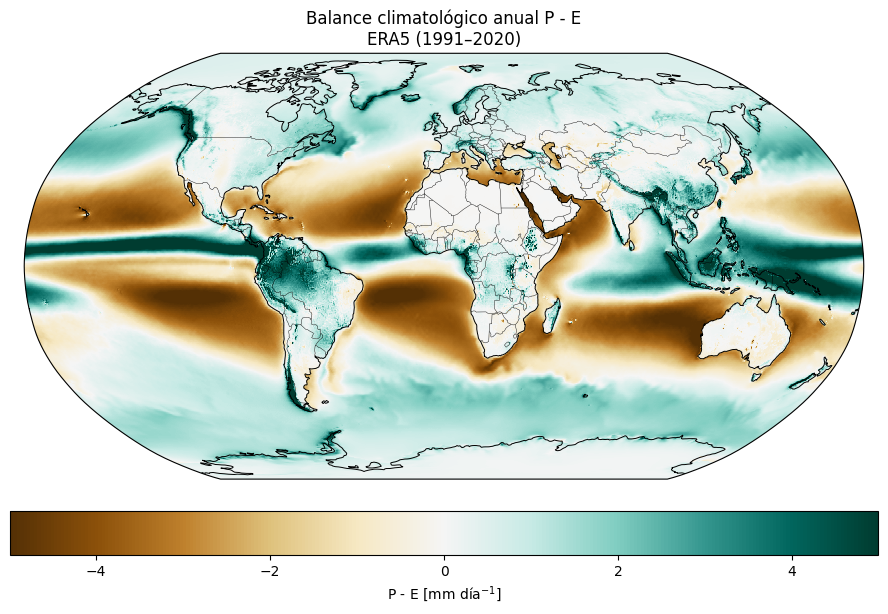

In [ ]:
import cartopy.crs as ccrs
import cartopy.feature as cfeature
import matplotlib.pyplot as plt
import numpy as np

fig = plt.figure(figsize=(14, 7))

ax = plt.axes(projection=ccrs.Robinson())

ax.set_global()
ax.coastlines(linewidth=0.7)

ax.add_feature( cfeature.BORDERS, linewidth=0.3)

# Escala simétrica para distinguir P>E y E>P
lim = float(np.nanpercentile(np.abs(PE_anual_map.values), 98))

mapa = ax.pcolormesh(PE_anual_map.longitude, PE_anual_map.latitude, PE_anual_map,transform=ccrs.PlateCarree(), cmap="BrBG", vmin=-lim, vmax=lim, shading="auto")

cbar = plt.colorbar(mapa, ax=ax, orientation="horizontal", pad=0.06, shrink=0.8)

cbar.set_label("P - E [mm día$^{-1}$]")

plt.title("Balance climatológico anual P - E\n"
    "ERA5 (1991–2020)")
plt.show()

In [ ]:
# Balance mensual espacial
PE_clim = P_clim - E_clim

# Febrero = mes 2
PE_feb = PE_clim.sel(month=2)

# Agosto = mes 8
PE_ago = PE_clim.sel(month=8)

In [ ]:
PE_feb_mex = PE_feb.sel(latitude=slice(33, 14), longitude=slice(242, 274))

PE_ago_mex = PE_ago.sel(latitude=slice(33, 14), longitude=slice(242, 274))

/usr/local/lib/python3.13/dist-packages/cartopy/io/__init__.py:263: DownloadWarning: Downloading: https://naturalearth.s3.amazonaws.com/50m_physical/ne_50m_coastline.zip
  warnings.warn(f'Downloading: {url}', DownloadWarning)
/usr/local/lib/python3.13/dist-packages/cartopy/io/__init__.py:263: DownloadWarning: Downloading: https://naturalearth.s3.amazonaws.com/50m_cultural/ne_50m_admin_0_boundary_lines_land.zip
  warnings.warn(f'Downloading: {url}', DownloadWarning)


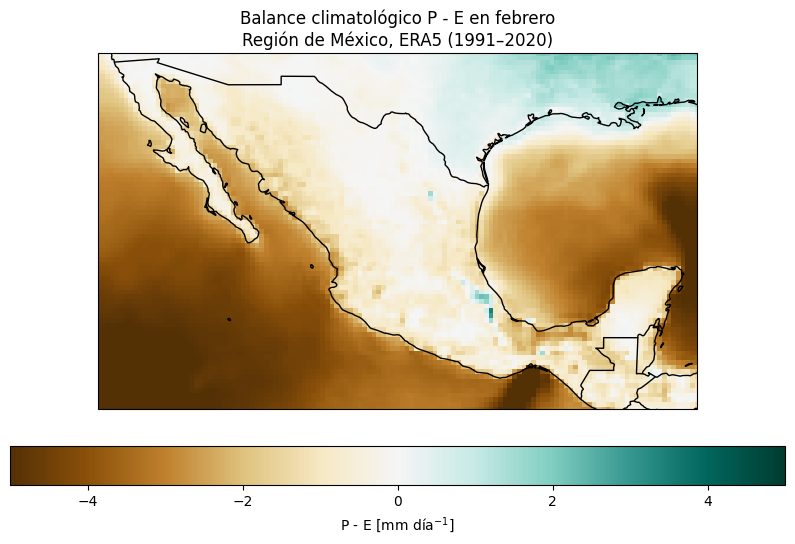

In [ ]:
fig = plt.figure(figsize=(10, 6))

ax = plt.axes(projection=ccrs.PlateCarree())

ax.set_extent([-118, -86, 14, 33], crs=ccrs.PlateCarree())

ax.coastlines()
ax.add_feature(cfeature.BORDERS)

# Convertimos 0-360 a -180-180 solo para graficar
lon_feb = ((PE_feb_mex.longitude + 180) % 360) - 180

lim_mex = 5

mapa = ax.pcolormesh(lon_feb, PE_feb_mex.latitude, PE_feb_mex, transform=ccrs.PlateCarree(), cmap="BrBG", vmin=-lim_mex, vmax=lim_mex, shading="auto")

cbar = plt.colorbar( mapa, ax=ax, orientation="horizontal", pad=0.08)

cbar.set_label("P - E [mm día$^{-1}$]")

ax.set_title("Balance climatológico P - E en febrero\n" "Región de México, ERA5 (1991–2020)")

plt.show()

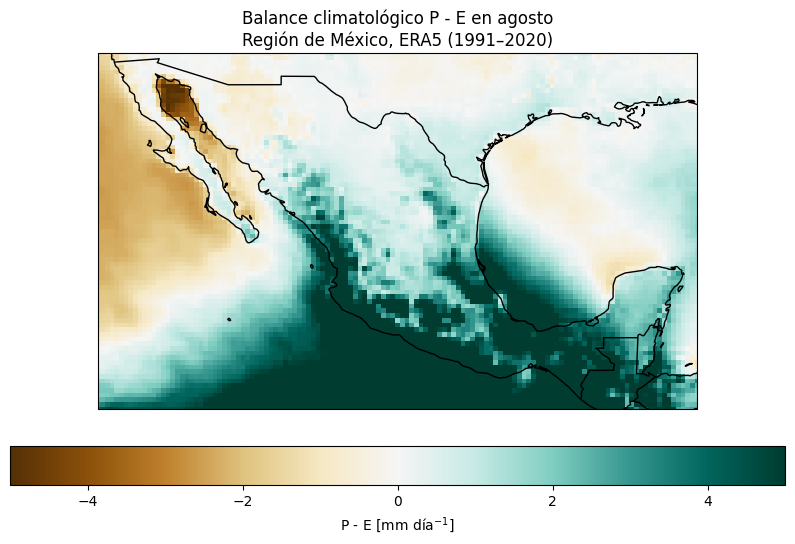

In [ ]:
fig = plt.figure(figsize=(10, 6))

ax = plt.axes(projection=ccrs.PlateCarree())

ax.set_extent([-118, -86, 14, 33], crs=ccrs.PlateCarree())

ax.coastlines()
ax.add_feature(cfeature.BORDERS)

lon_ago = ((PE_ago_mex.longitude + 180) % 360) - 180

mapa = ax.pcolormesh( lon_ago, PE_ago_mex.latitude, PE_ago_mex, transform=ccrs.PlateCarree(), cmap="BrBG", vmin=-lim_mex, vmax=lim_mex, shading="auto")

cbar = plt.colorbar(mapa, ax=ax, orientation="horizontal", pad=0.08)

cbar.set_label("P - E [mm día$^{-1}$]")

ax.set_title("Balance climatológico P - E en agosto\n""Región de México, ERA5 (1991–2020)")

plt.show()


**Distribución espacial de \(P-E\)**

El balance climatológico anual presenta una marcada estructura espacial. Se observan regiones con \(P-E>0\), donde la precipitación supera a la evaporación, así como regiones con \(P-E<0), donde la evaporación es mayor. A diferencia del promedio global, que presenta un balance cercano a cero, el análisis espacial muestra importantes desequilibrios regionales. Esto indica que el cierre global no implica un equilibrio local entre precipitación y evaporación, ya que el transporte atmosférico de humedad redistribuye agua entre distintas regiones del planeta.

Comparación estacional de \(P-E\). La distribución espacial del balance \(P-E\) presenta un marcado cambio entre febrero y agosto. Durante febrero predominan valores negativos en gran parte de la región analizada, indicando que la evaporación supera a la precipitación. En agosto se observa un incremento importante de \(P-E\), con valores positivos principalmente en el centro-sur y sur de México. Este contraste espacial es consistente con la amplitud estacional regional de 3.761 mm día^-1 obtenida a partir de los promedios regionales.

**Conclusión**

En esta práctica se analizó el balance climatológico entre precipitación y evaporación utilizando datos del reanálisis ERA5 para el periodo 1991–2020. A escala global se obtuvo una precipitación media de 2.9286 mm día^-1 y una evaporación media de 2.9057 mm día^-1, dando como resultado un balance P-E=+0.0229 mm día^-1. La diferencia representa un error relativo de cierre de aproximadamente 0.78 %, por lo que el balance hidrológico global obtenido es cercano a cero.
Al realizar el análisis regional para México se encontró un comportamiento diferente. El balance \(P-E\) presentó una marcada variación estacional, alcanzando un máximo de +1.758 mm día^-1 en agosto y un mínimo de -2.003 mm día^-1 en febrero, con una amplitud estacional de 3.761 mm día^-1. Los mapas climatológicos permitieron observar espacialmente este contraste: durante febrero predominaron valores negativos de \(P-E\), mientras que en agosto aumentaron considerablemente los valores positivos, principalmente hacia el centro-sur y sur de México.
Los resultados muestran que un balance global cercano a cero no implica que precipitación y evaporación se encuentren equilibradas en cada región. Mientras que globalmente ambas cantidades tienden a compensarse, regionalmente pueden presentarse importantes excedentes o déficits de precipitación respecto a evaporación y una marcada dependencia estacional.
El procedimiento contemplaba complementar esta interpretación mediante el transporte atmosférico integrado de humedad. Sin embargo, esta parte no pudo completarse debido a dificultades técnicas para procesar el archivo GRIB correspondiente. Por ello, no se presentan resultados cuantitativos del transporte de humedad ni de su divergencia. Aun así, los resultados obtenidos con \(P\), \(E\) y \(P-E\) permiten identificar claramente las diferencias entre el comportamiento hidrológico global y regional durante el periodo climatológico analizado.